In [131]:
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.ticker import MultipleLocator

DATA_PATH = "./archive/"
FILE_NAMES = ["2015.csv", "2016.csv", "2017.csv", "2018.csv", "2019.csv"]

def read_csv_data(data_path):
    """
    Lee un archivo csv y retorna un dataframe
    Args:
        data_path: str, ruta del archivo csv
    Returns:
        df: pd.DataFrame, dataframe con los datos del archivo csv
    """
    # Si la ruta del archivo está vacía, retorna None
    if data_path is None or len(data_path) == 0:
        print("La ruta del archivo está vacía")
        return None
    
    try:
        df = pd.read_csv(data_path)
        return df
    except FileNotFoundError:
        # Si el archivo no se encuentra, retorna None
        print(f"No se pudo encontrar el archivo en la ruta: {data_path}")
        return None
    except Exception as e:
        # Si ocurre un error, retorna None
        print(f"Error al leer el archivo: {e}")
        return None

def refactor_headers(df):
    """
    Refactoriza los headers del dataframe a minúsculas y sin espacios
    Args:
        df: pd.DataFrame, dataframe a refactorizar
    Returns:
        df: pd.DataFrame, dataframe con los headers refactorizados
    """
    if df is None or df.empty:
        # Si el dataframe está vacío o es None, retorna None
        print("El dataframe está vacío o es None")
        return None
    
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    rename_map = {
        'score': 'happiness_score',
        'happiness.score': 'happiness_score',
        'economy_(gdp_per_capita)': 'gdp_per_capita',
        'economy..gdp.per.capita.': 'gdp_per_capita',
        'gdp per capita': 'gdp_per_capita',
        'health_(life_expectancy)': 'health_life_expectancy',
        'health_(life_expectancy)': 'health_life_expectancy',
        'health..life.expectancy.': 'health_life_expectancy',
        'healthy_life_expectancy': 'health_life_expectancy',
        'freedom': 'freedom_to_make_life_choices',
    }
    
    df = df.rename(columns=rename_map)
    return df

dataFrames = []
for i in FILE_NAMES:
    df = read_csv_data(DATA_PATH + i)
    df = refactor_headers(df)
    dataFrames.append(df)
    df = None

print(dataFrames[0].head())

       country          region  happiness_rank  happiness_score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   standard_error  gdp_per_capita   family  health_life_expectancy  \
0         0.03411         1.39651  1.34951                 0.94143   
1         0.04884         1.30232  1.40223                 0.94784   
2         0.03328         1.32548  1.36058                 0.87464   
3         0.03880         1.45900  1.33095                 0.88521   
4         0.03553         1.32629  1.32261                 0.90563   

   freedom_to_make_life_choices  trust_(government_corruption)  generosity  \
0                       0.66557                        0.41978     0.29678   
1                   

In [132]:
for dataframe in dataFrames:
    print(dataframe.columns)

Index(['country', 'region', 'happiness_rank', 'happiness_score',
       'standard_error', 'gdp_per_capita', 'family', 'health_life_expectancy',
       'freedom_to_make_life_choices', 'trust_(government_corruption)',
       'generosity', 'dystopia_residual'],
      dtype='object')
Index(['country', 'region', 'happiness_rank', 'happiness_score',
       'lower_confidence_interval', 'upper_confidence_interval',
       'gdp_per_capita', 'family', 'health_life_expectancy',
       'freedom_to_make_life_choices', 'trust_(government_corruption)',
       'generosity', 'dystopia_residual'],
      dtype='object')
Index(['country', 'happiness.rank', 'happiness_score', 'whisker.high',
       'whisker.low', 'gdp_per_capita', 'family', 'health_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'trust..government.corruption.', 'dystopia.residual'],
      dtype='object')
Index(['overall_rank', 'country_or_region', 'happiness_score',
       'gdp_per_capita', 'social_support', '

# Crear Histogramas: 

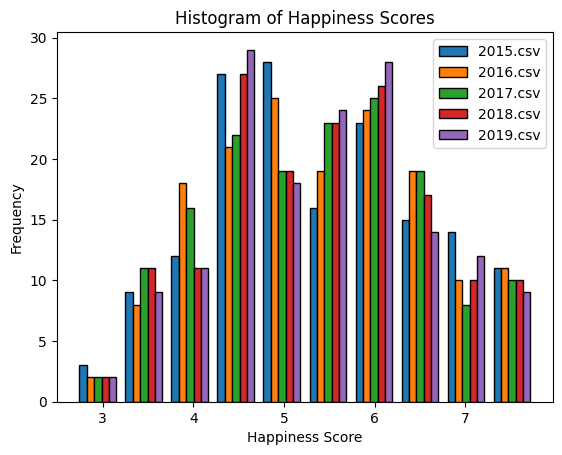

In [133]:
data_scores_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['happiness_score'] is not None:
        data = dataFrames[i]['happiness_score'].tolist()
        data_scores_histogram.append(data)
        data = None

plt.hist(data_scores_histogram, bins=10, edgecolor='black', alpha=1)
plt.legend(FILE_NAMES)
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.title('Histogram of Happiness Scores')
plt.show()

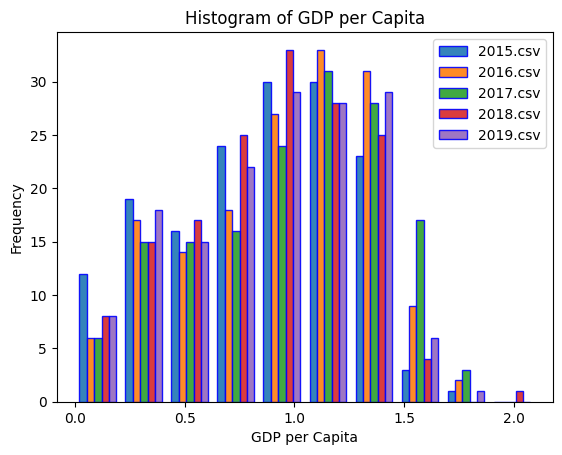

In [134]:
data_gdp_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['gdp_per_capita'] is not None:
        data = dataFrames[i]['gdp_per_capita'].tolist()
        data_gdp_histogram.append(data)
        data = None

plt.hist(data_gdp_histogram, bins=10, edgecolor='blue', alpha=0.9)
plt.legend(FILE_NAMES)
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.title('Histogram of GDP per Capita')
plt.show()

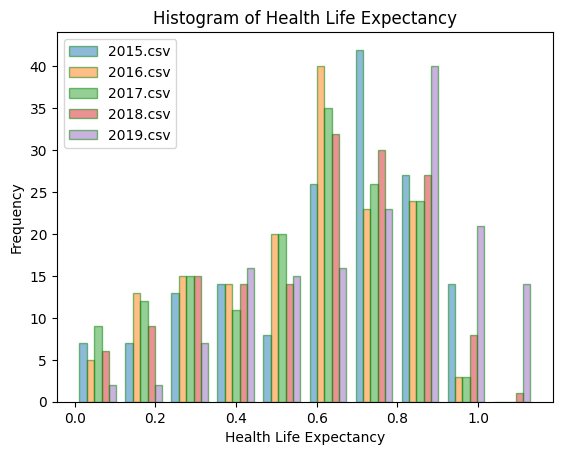

In [135]:
data_health_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['health_life_expectancy'] is not None:
        data = dataFrames[i]['health_life_expectancy'].tolist()
        data_health_histogram.append(data)
        data = None

plt.hist(data_health_histogram, bins=10, edgecolor='green', alpha=0.5)
plt.legend(FILE_NAMES)
plt.xlabel('Health Life Expectancy')
plt.ylabel('Frequency')
plt.title('Histogram of Health Life Expectancy')
plt.show()

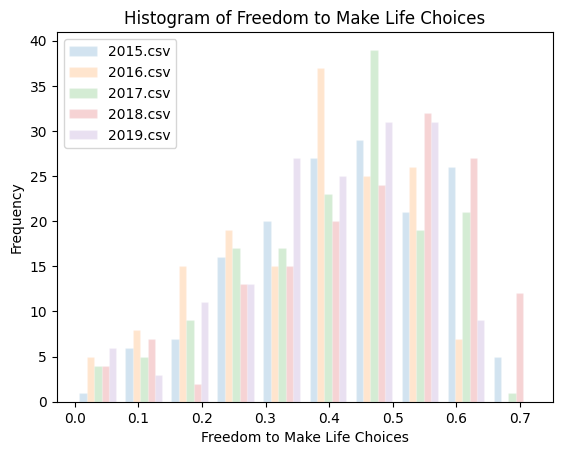

In [136]:
data_freedom_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['freedom_to_make_life_choices'] is not None:
        data = dataFrames[i]['freedom_to_make_life_choices'].tolist()
        data_freedom_histogram.append(data)
        data = None

plt.hist(data_freedom_histogram, bins=10, edgecolor='white', alpha=0.2)
plt.legend(FILE_NAMES)
plt.xlabel('Freedom to Make Life Choices')
plt.ylabel('Frequency')
plt.title('Histogram of Freedom to Make Life Choices')
plt.show()

# Crear Boxplots: 

/var/folders/vf/bxc814d931b8lh0s326gdk7xdsgnj0/T/ipykernel_63713/977476652.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


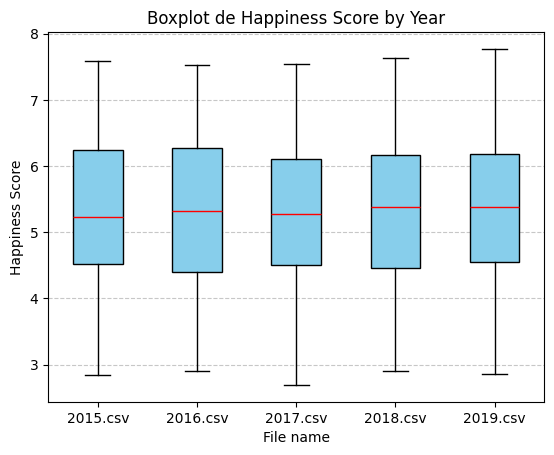

In [137]:
# Preparar los datos para el boxplot de Happiness Score
data_score_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['happiness_score'] is not None:
        data = dataFrames[i]['happiness_score'].tolist()
        data_score_histogram.append(data)
        data = None

# Crear el boxplot
plt.boxplot(
    data_score_histogram, 
    labels=FILE_NAMES, 
    patch_artist=True, 
    boxprops=dict(
        facecolor='skyblue', 
        color='black',
    ), 
    medianprops=dict(color='red'),
)

# Añadir títulos y etiquetas
plt.title('Boxplot de Happiness Score by Year')
plt.ylabel('Happiness Score')
plt.xlabel('File name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

/var/folders/vf/bxc814d931b8lh0s326gdk7xdsgnj0/T/ipykernel_63713/3901992751.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


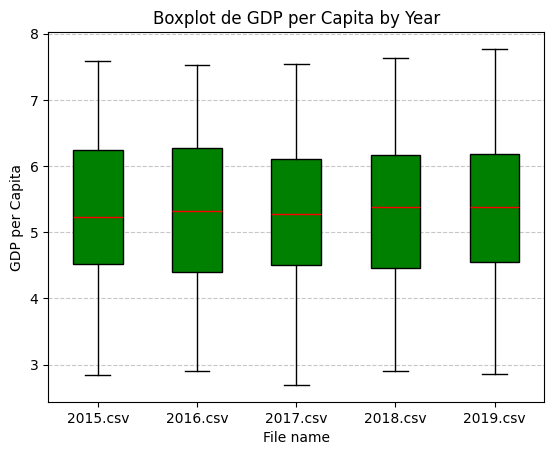

In [138]:
# Preparar los datos para el boxplot de Happiness Score
data_gdp_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['gdp_per_capita'] is not None:
        data = dataFrames[i]['gdp_per_capita'].tolist()
        data_gdp_histogram.append(data)
        data = None

# Crear el boxplot
plt.boxplot(
    data_score_histogram, 
    labels=FILE_NAMES, 
    patch_artist=True, 
    boxprops=dict(
        facecolor='green', 
        color='black',
    ), 
    medianprops=dict(color='red'),
)

# Añadir títulos y etiquetas
plt.title('Boxplot de GDP per Capita by Year')
plt.ylabel('GDP per Capita')
plt.xlabel('File name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

/var/folders/vf/bxc814d931b8lh0s326gdk7xdsgnj0/T/ipykernel_63713/2998506802.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


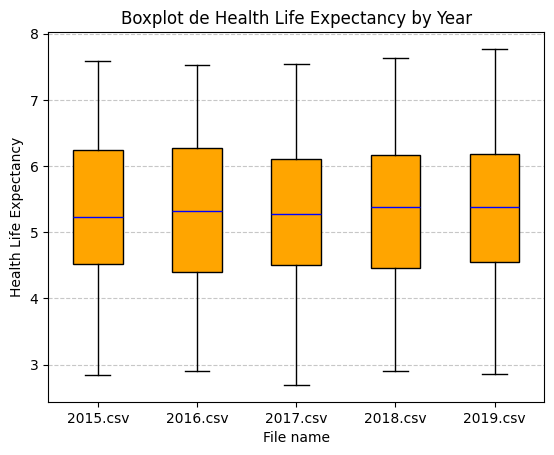

In [139]:
# Preparar los datos para el boxplot de Happiness Score
data_health_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['health_life_expectancy'] is not None:
        data = dataFrames[i]['health_life_expectancy'].tolist()
        data_health_histogram.append(data)
        data = None

# Crear el boxplot
plt.boxplot(
    data_score_histogram, 
    labels=FILE_NAMES, 
    patch_artist=True, 
    boxprops=dict(
        facecolor='orange', 
        color='black',
    ), 
    medianprops=dict(color='blue'),
)

# Añadir títulos y etiquetas
plt.title('Boxplot de Health Life Expectancy by Year')
plt.ylabel('Health Life Expectancy')
plt.xlabel('File name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

/var/folders/vf/bxc814d931b8lh0s326gdk7xdsgnj0/T/ipykernel_63713/3436840794.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


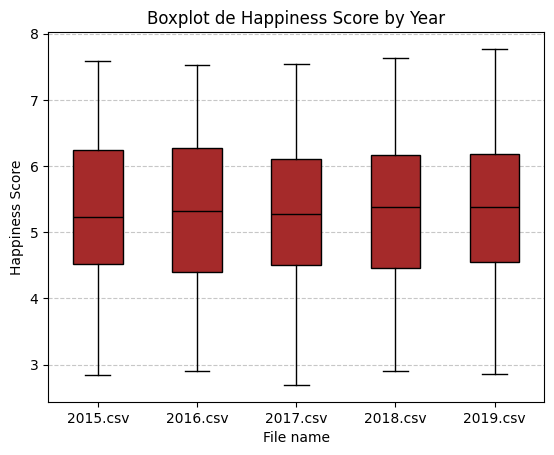

In [140]:
# Preparar los datos para el boxplot de Happiness Score
data_freedom_histogram = []
for i in range(len(dataFrames)):
    if dataFrames[i]['freedom_to_make_life_choices'] is not None:
        data = dataFrames[i]['freedom_to_make_life_choices'].tolist()
        data_freedom_histogram.append(data)
        data = None

# Crear el boxplot
plt.boxplot(
    data_score_histogram, 
    labels=FILE_NAMES, 
    patch_artist=True, 
    boxprops=dict(
        facecolor='brown', 
        color='black',
    ), 
    medianprops=dict(color='black'),
)

# Añadir títulos y etiquetas
plt.title('Boxplot de Happiness Score by Year')
plt.ylabel('Happiness Score')
plt.xlabel('File name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

# Análisis Combinado: 

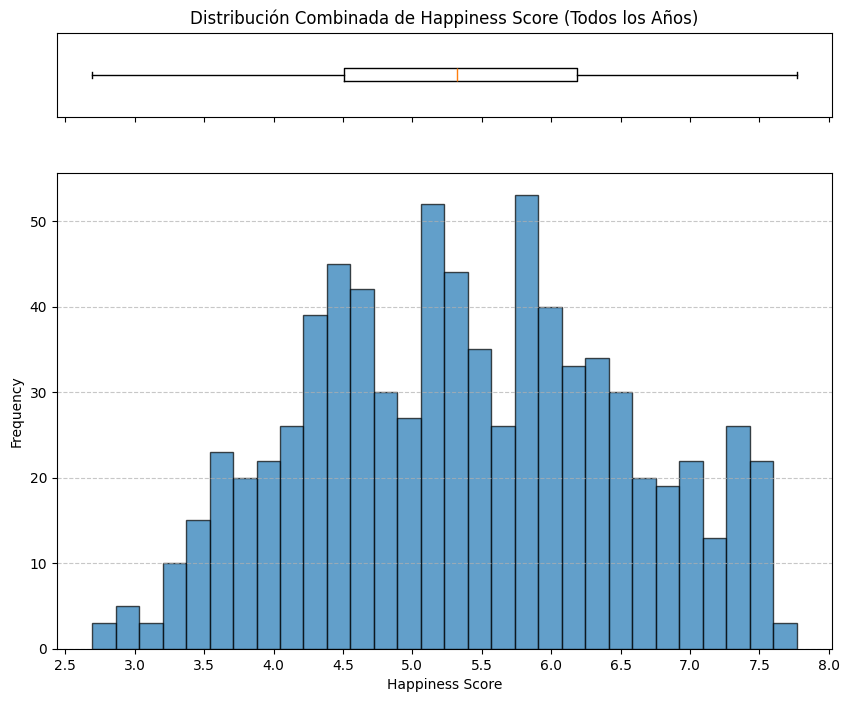

In [141]:
# Se combinan los datos de 'happiness_score' de todos los años en una sola serie
all_happiness_scores = pd.concat([df['happiness_score'].dropna() for df in dataFrames])

# Se crea una figura con dos subplots que comparten el eje x
# Usamos gridspec_kw para dar más espacio al histograma que al boxplot
_, (ax_box, ax_hist) = plt.subplots(
    2, 
    sharex=True, 
    figsize=(10, 8),
    gridspec_kw={"height_ratios": (.15, .85)}
)

# Crear el boxplot en el subplot superior (ax_box)
ax_box.boxplot(all_happiness_scores, vert=False)
ax_box.set_yticks([]) # Ocultar los ticks del eje y del boxplot
ax_box.set_title('Distribución Combinada de Happiness Score (Todos los Años)')
ax_box.xaxis.set_major_locator(MultipleLocator(0.5))

# Crear el histograma en el subplot inferior (ax_hist)
ax_hist.hist(all_happiness_scores, bins=30, edgecolor='black', alpha=0.7)
ax_hist.set_xlabel('Happiness Score')
ax_hist.set_ylabel('Frequency')
ax_hist.xaxis.set_major_locator(MultipleLocator(0.5))

ax_hist.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

Se observa que la mayoría de los paises tienen Happiness Score entre 4.5 y 6.2 aproximadamente, teniendo valores mínimos de 2.8, y máximo de 7.8 aproximadamente. A su vez, se observa que la mediana de estos sería de 5.3 aproximadamente. 

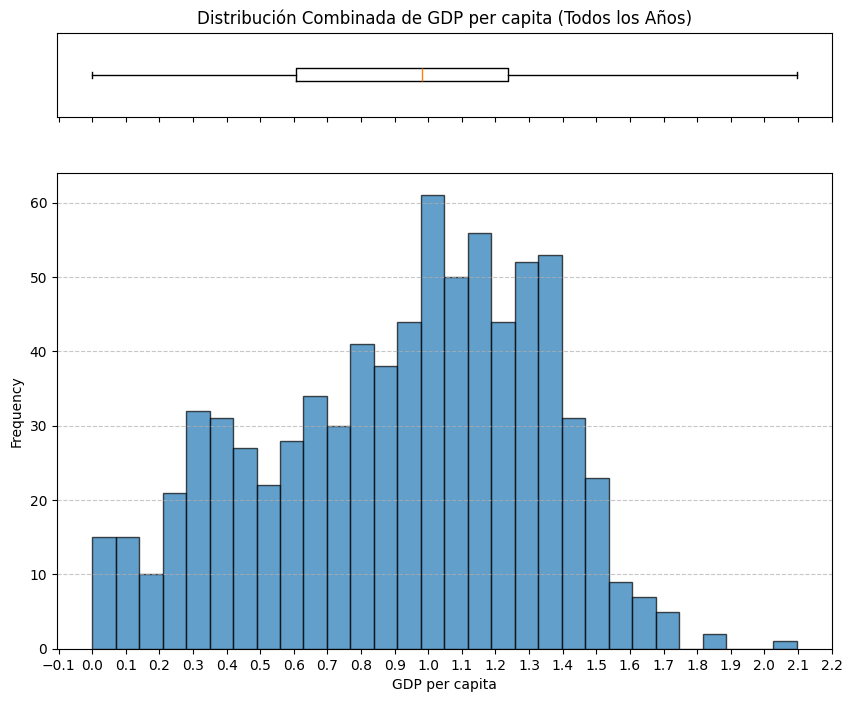

In [ ]:
# Se combinan los datos de 'happiness_score' de todos los años en una sola serie
all_gdp_per_capita = pd.concat([df['gdp_per_capita'].dropna() for df in dataFrames])

# Se crea una figura con dos subplots que comparten el eje x
# Usamos gridspec_kw para dar más espacio al histograma que al boxplot
_, (ax_box, ax_hist) = plt.subplots(
    2, 
    sharex=True, 
    figsize=(10, 8),
    gridspec_kw={"height_ratios": (.15, .85)}
)

# Crear el boxplot en el subplot superior (ax_box)
multiple_locator = MultipleLocator(0.1)
ax_box.boxplot(all_gdp_per_capita, vert=False)
ax_box.set_yticks([]) # Ocultar los ticks del eje y del boxplot
ax_box.set_title('Distribución Combinada de GDP per capita (Todos los Años)')
ax_box.xaxis.set_major_locator(multiple_locator)

# Crear el histograma en el subplot inferior (ax_hist)
ax_hist.hist(all_gdp_per_capita, bins=30, edgecolor='black', alpha=0.7)
ax_hist.set_xlabel('GDP per capita')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(axis='y', linestyle='--', alpha=0.7)
ax_hist.xaxis.set_major_locator(multiple_locator)

# Mostrar el gráfico
plt.show()

Se observa que el GDP per capita se encuentra entre 0.6 y 1.2. Tambien se observa que la media del GPD per capita es de 1.0. Por otro lado, se presentan mínimos de 0.0 y máximos de 2.1. El boxplot muestra que la distribución está inclinada hacia la izquierda, por lo que los valores de GDP son en su mayoría más bajos. 

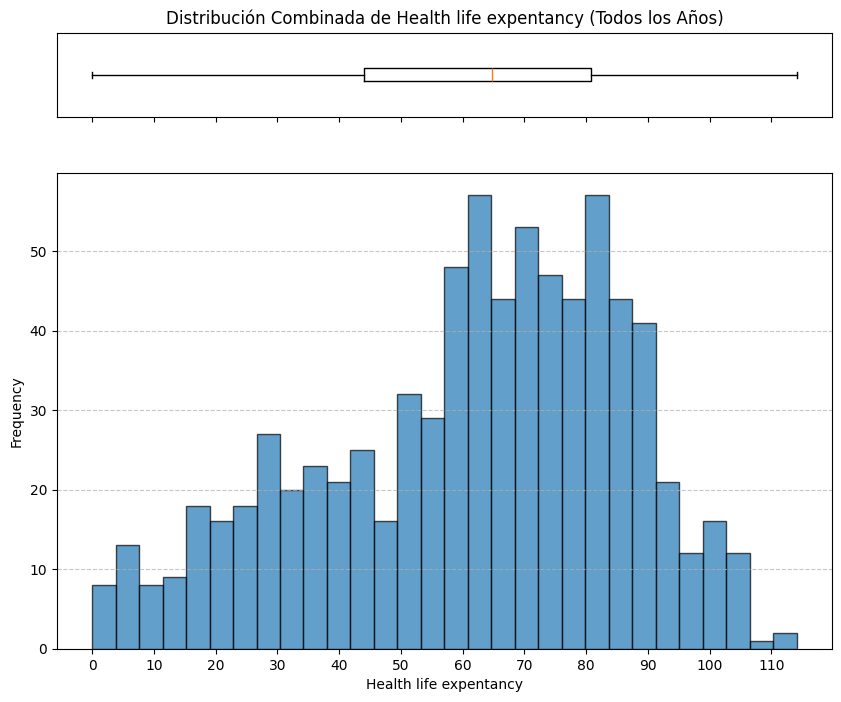

In [ ]:
# Se combinan los datos de 'happiness_score' de todos los años en una sola serie
all_health_life = pd.concat([df['health_life_expectancy'].dropna() for df in dataFrames])
all_health_life = all_health_life * 100

# Se crea una figura con dos subplots que comparten el eje x
# Usamos gridspec_kw para dar más espacio al histograma que al boxplot
_, (ax_box, ax_hist) = plt.subplots(
    2, 
    sharex=True, 
    figsize=(10, 8),
    gridspec_kw={"height_ratios": (.15, .85)}
)

# Crear el boxplot en el subplot superior (ax_box)
multiple_locator = MultipleLocator(10)
ax_box.boxplot(all_health_life, vert=False)
ax_box.set_yticks([]) # Ocultar los ticks del eje y del boxplot
ax_box.set_title('Distribución Combinada de Health life expentancy (Todos los Años)')
ax_box.xaxis.set_major_locator(multiple_locator)

# Crear el histograma en el subplot inferior (ax_hist)
ax_hist.hist(all_health_life, bins=30, edgecolor='black', alpha=0.7)
ax_hist.set_xlabel('Health life expentancy')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(axis='y', linestyle='--', alpha=0.7)
ax_hist.xaxis.set_major_locator(multiple_locator)

# Mostrar el gráfico
plt.show()

Se observa que el Health life expentancy, la mayoría de paises se encuentran entre 40 y 90 años, con un promedio de 65. Se presentan valores mínimos de 0 y valores máximos de 110 años. El boxplot nos muestra los valores atípicos en los extremos, indicando una amplia variabilidad de esta variable entre los paises. 

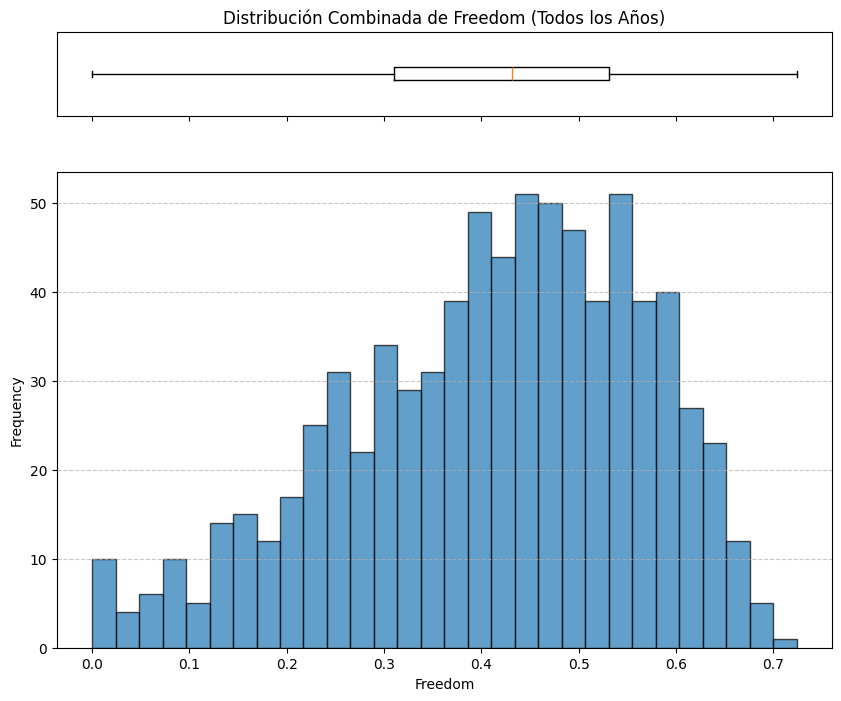

In [ ]:
# Se combinan los datos de 'happiness_score' de todos los años en una sola serie
all_freedom = pd.concat([df['freedom_to_make_life_choices'].dropna() for df in dataFrames])

# Se crea una figura con dos subplots que comparten el eje x
# Usamos gridspec_kw para dar más espacio al histograma que al boxplot
_, (ax_box, ax_hist) = plt.subplots(
    2, 
    sharex=True, 
    figsize=(10, 8),
    gridspec_kw={"height_ratios": (.15, .85)}
)

# Crear el boxplot en el subplot superior (ax_box)
multiple_locator = MultipleLocator(0.1)
ax_box.boxplot(all_freedom, vert=False)
ax_box.set_yticks([]) # Ocultar los ticks del eje y del boxplot
ax_box.set_title('Distribución Combinada de Freedom (Todos los Años)')
ax_box.xaxis.set_major_locator(multiple_locator)

# Crear el histograma en el subplot inferior (ax_hist)
ax_hist.hist(all_freedom, bins=30, edgecolor='black', alpha=0.7)
ax_hist.set_xlabel('Freedom')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(axis='y', linestyle='--', alpha=0.7)
ax_hist.xaxis.set_major_locator(multiple_locator)

# Mostrar el gráfico
plt.show()

Se observa que el índice de Freedom se encuentra entre 0.3 y 0.5 aproximadamente. A su vex, se observa en el histograma que está desplazado hacia la derecha, lo que indica que la mayoría de los paises tienen un alto porcentaje de este índice. A su vez, el bloxplot nos indica los valores mínimos de 0, y máximos al 0.7. Esto indica que la libertad para tomar desiciones en distinos paises es significativamente variada. 